In [3]:
from PIL import Image
import numpy as np
import glob

In [4]:
widthRatio = []
heightRatio = []

for file in sorted(glob.glob('../Data/Aiden/*.jpg')):
    img = np.array(Image.open(file), dtype = np.int32)
    widthRatio.append(img.shape[1])
    heightRatio.append(img.shape[0])

for file in sorted(glob.glob('../Data/Andrew/*.jpg')):
    img = np.array(Image.open(file), dtype = np.int32)
    widthRatio.append(img.shape[1])
    heightRatio.append(img.shape[0])

for file in sorted(glob.glob('../Data/Cathy/*.jpg')):
    img = np.array(Image.open(file), dtype = np.int32)
    widthRatio.append(img.shape[1])
    heightRatio.append(img.shape[0])

In [5]:
print('전체 너비 평균 해상도 :', np.mean(widthRatio))
print('전체 높이 평균 해상도 :', np.mean(heightRatio))

전체 너비 평균 해상도 : 277.7962962962963
전체 높이 평균 해상도 : 330.35185185185185


In [12]:
i = 1
for file in sorted(glob.glob('../Data/Aiden/*.jpg')):
    img = Image.open(file)
    imgResize = img.resize((278, 331), Image.Resampling.LANCZOS)
    imgResize = imgResize.convert('L')
    imgResize.save(f'../Data/AidenNew/image_{i:02}.jpg', "JPEG") # f-string 문법. i:02 -> 십의자리 까지 지정한다
    i += 1

In [13]:
i = 1
for file in sorted(glob.glob('../Data/Andrew/*.jpg')):
    img = Image.open(file)
    imgResize = img.resize((278, 331), Image.Resampling.LANCZOS)
    imgResize = imgResize.convert('L')
    imgResize.save(f'../Data/AndrewNew/image_{i:02}.jpg', "JPEG") # f-string 문법. i:02 -> 십의자리 까지 지정한다
    i += 1

In [14]:
i = 1
for file in sorted(glob.glob('../Data/Cathy/*.jpg')):
    img = Image.open(file)
    imgResize = img.resize((278, 331), Image.Resampling.LANCZOS)
    imgResize = imgResize.convert('L')
    imgResize.save(f'../Data/CathyNew/image_{i:02}.jpg', "JPEG") # f-string 문법. i:02 -> 십의자리 까지 지정한다
    i += 1

In [10]:
number_of_data = 18
img_width_size = 278
img_height_size = 331

In [15]:
AidenData = np.zeros(
    number_of_data * img_width_size * img_height_size,
    dtype = np.int32
).reshape(
    number_of_data,
    img_height_size,
    img_width_size
)
AidenData.shape

(18, 331, 278)

In [16]:
i = 0
for file in sorted(glob.glob('../Data/AidenNew/*.jpg')):
    img = np.array(Image.open(file), dtype = np.int32)
    AidenData[i, :, :] = img
    i += 1
AidenData.shape

(18, 331, 278)

In [17]:
AndrewData = np.zeros(
    number_of_data * img_width_size * img_height_size,
    dtype = np.int32
).reshape(
    number_of_data,
    img_height_size,
    img_width_size
)

i = 0
for file in sorted(glob.glob('../Data/AndrewNew/*.jpg')):
    img = np.array(Image.open(file), dtype = np.int32)
    AndrewData[i, :, :] = img
    i += 1
AndrewData.shape

(18, 331, 278)

In [18]:
CathyData = np.zeros(
    number_of_data * img_width_size * img_height_size,
    dtype = np.int32
).reshape(
    number_of_data,
    img_height_size,
    img_width_size
)

i = 0
for file in sorted(glob.glob('../Data/CathyNew/*.jpg')):
    img = np.array(Image.open(file), dtype = np.int32)
    CathyData[i, :, :] = img
    i += 1
CathyData.shape

(18, 331, 278)

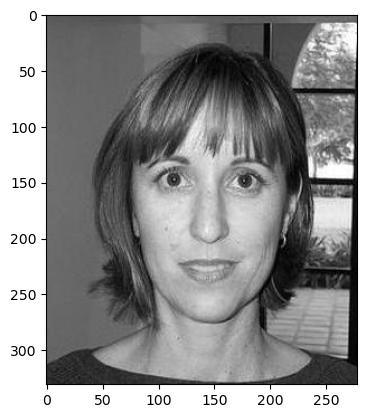

In [22]:
# 이미지 확인하기
import matplotlib.pyplot as plt
plt.imshow(CathyData[0].reshape(img_height_size, img_width_size), cmap='gray')
plt.show()

In [23]:
train = np.concatenate(
    [AidenData, AndrewData, CathyData]
)
train.shape

(54, 331, 278)

In [24]:
target = np.concatenate(
    [np.zeros(18), np.ones(18), np.full(18, 2)]
)
target.shape

(54,)

In [25]:
from sklearn.model_selection import train_test_split
train_data, test_data, train_target, test_target = \
    train_test_split(
        train,
        target,
        test_size=0.2,
        random_state=42
    )

# 크기 확인
print(train_data.shape)
print(test_data.shape)
print(train_target.shape)
print(test_target.shape)

(43, 331, 278)
(11, 331, 278)
(43,)
(11,)


> 참고, train_test_split()함수 test, train 나누는 원리 : test = test_size * 전체 데이터 수, 반올림 처리 하여 정수로 만듦.  
train = (전체 데이터 수) - test

Epoch 1/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 3s/step - accuracy: 0.1765 - loss: 1.6421 - val_accuracy: 0.5556 - val_loss: 6.8083
Epoch 2/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.2647 - loss: 12.4127 - val_accuracy: 0.5556 - val_loss: 3.2600
Epoch 3/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.2353 - loss: 8.7283 - val_accuracy: 0.3333 - val_loss: 1.8312
Epoch 4/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.5000 - loss: 3.0616 - val_accuracy: 0.0000e+00 - val_loss: 1.7112
Epoch 5/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.3529 - loss: 1.5087 - val_accuracy: 0.0000e+00 - val_loss: 1.1992
Epoch 6/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.4706 - loss: 0.9726 - val_accuracy: 0.5556 - val_loss: 1.0619
Epoch 7/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 368ms/step - accuracy: 0.7353 - loss: 0.9051 - val_accuracy: 0.0000e+00 - val_loss: 1.2639
Epoch 8/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 365ms/step - accuracy: 0.5294 - loss: 0.9214 - val_accuracy: 0.4444 - val_loss: 1.16

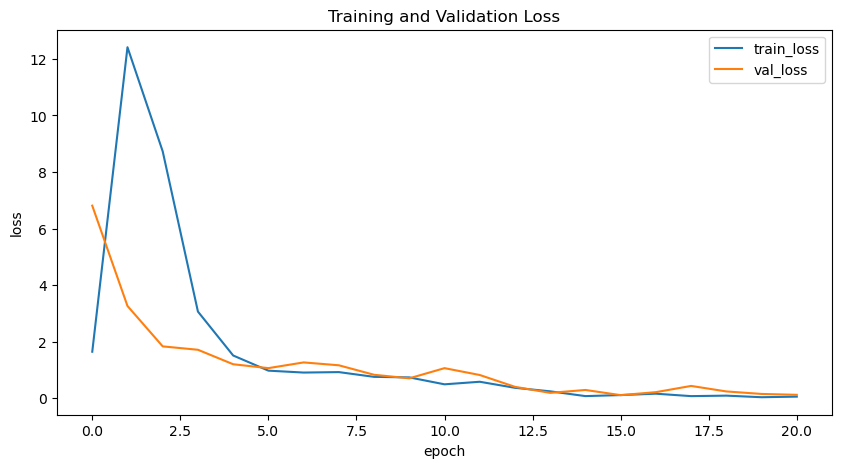

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9091 - loss: 0.2080

🥇 최적의 에포크: 16 epoch
--------------------------------------------------
📈 [Train]       훈련 정확도: 97.06%
🧪 [Validation]  검증 정확도: 100.00%
🎯 [Test]        🎯 최종 테스트 정확도: 90.91%


In [26]:
# CNN
import matplotlib.pyplot as plt
from tensorflow import keras

# 픽셀값을 0~1 사이로 정규화하고 채널 차원(1) 추가
train_scaled = train_data.reshape(-1, img_height_size, img_width_size, 1) / 255.0
test_scaled = test_data.reshape(-1, img_height_size, img_width_size, 1) / 255.0

# 검증 세트 분리
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42
)

# CNN 모델 구축
model = keras.Sequential(
    [
        keras.Input(shape=(img_height_size, img_width_size, 1)),
        # 합성곱 층 1
        keras.layers.Conv2D(
            32,
            kernel_size=3,
            activation="relu",
            padding="same",
        ),
        keras.layers.MaxPooling2D(2),
        # 합성곱 층 2
        keras.layers.Conv2D(
            64, kernel_size=3, activation="relu", padding="same"
        ),
        keras.layers.MaxPooling2D(2),
        # 1차원으로 펼치기
        keras.layers.Flatten(),
        # 은닉층
        keras.layers.Dense(100, activation="relu"),
        keras.layers.Dense(50, activation="relu"),
        # 드롭아웃 (과대적합 방지)
        keras.layers.Dropout(0.5),
        # 출력층
        keras.layers.Dense(3, activation="softmax"),
    ]
)

# 모델 컴파일
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

# 콜백 설정 및 모델 학습
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    "faces.keras", save_best_only=True
)
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=5, restore_best_weights=True
)

history = model.fit(
    train_scaled,
    train_target,
    epochs=40,
    validation_data=(val_scaled, val_target),
    callbacks=[checkpoint_cb, early_stopping_cb]
)

# 학습 결과 시각화 (손실 그래프)
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()

# 테스트 세트 모델 평가
model.evaluate(test_scaled, test_target)

# 최적의 에포크 인덱스 찾기 (검증 손실이 가장 낮았던 시점 기준)
val_loss_list = history.history['val_loss'] # -> model.fit() 함수 실행 결과가 자동으로 history 딕셔너리 변수에 저장됨. 해당 변수에 loss, accuracy, val_loss, val_accuracy 등이 저장됨.
best_epoch_index = np.argmin(val_loss_list) # 리스트 인덱스 (0부터 시작)
best_epoch = best_epoch_index + 1               # 실제 에포크 차수 (1부터 시작)

# 최적 에포크 시점의 Train 및 Valid 정확도 추출
best_train_accuracy = history.history['accuracy'][best_epoch_index]
best_val_accuracy = history.history['val_accuracy'][best_epoch_index]

# 가장 성능이 좋았던 저장된 모델을 불러와 Test 정확도 측정
best_model = keras.models.load_model('faces.keras')
test_loss, best_test_accuracy = best_model.evaluate(test_scaled, test_target, verbose=0)

# 최종 결과 출력
print("\n" + "="*50)
print(f"🥇 최적의 에포크: {best_epoch} epoch")
print("-"*50)
print(f"📈 [Train]       훈련 정확도: {best_train_accuracy * 100:.2f}%")
print(f"🧪 [Validation]  검증 정확도: {best_val_accuracy * 100:.2f}%")
print(f"🎯 [Test]        🎯 최종 테스트 정확도: {best_test_accuracy * 100:.2f}%")
print("="*50)

> 이전에도 설명했던 내용에 추가 설명. 현재 모델에서는 DropOut 을 적용시켰는데, Train 중에는 50% 정도의 뉴런만 사용한 반면, Validation 정확도 측정시에는 100% 뉴런을 활용하기 때문에 Val > Train 현상이 발생할 수 있음.  
물론, 데이터 수가 매우 적기 때문에 '우연'의 일치로 잘 맞춘 경우가 있을 수 있음.

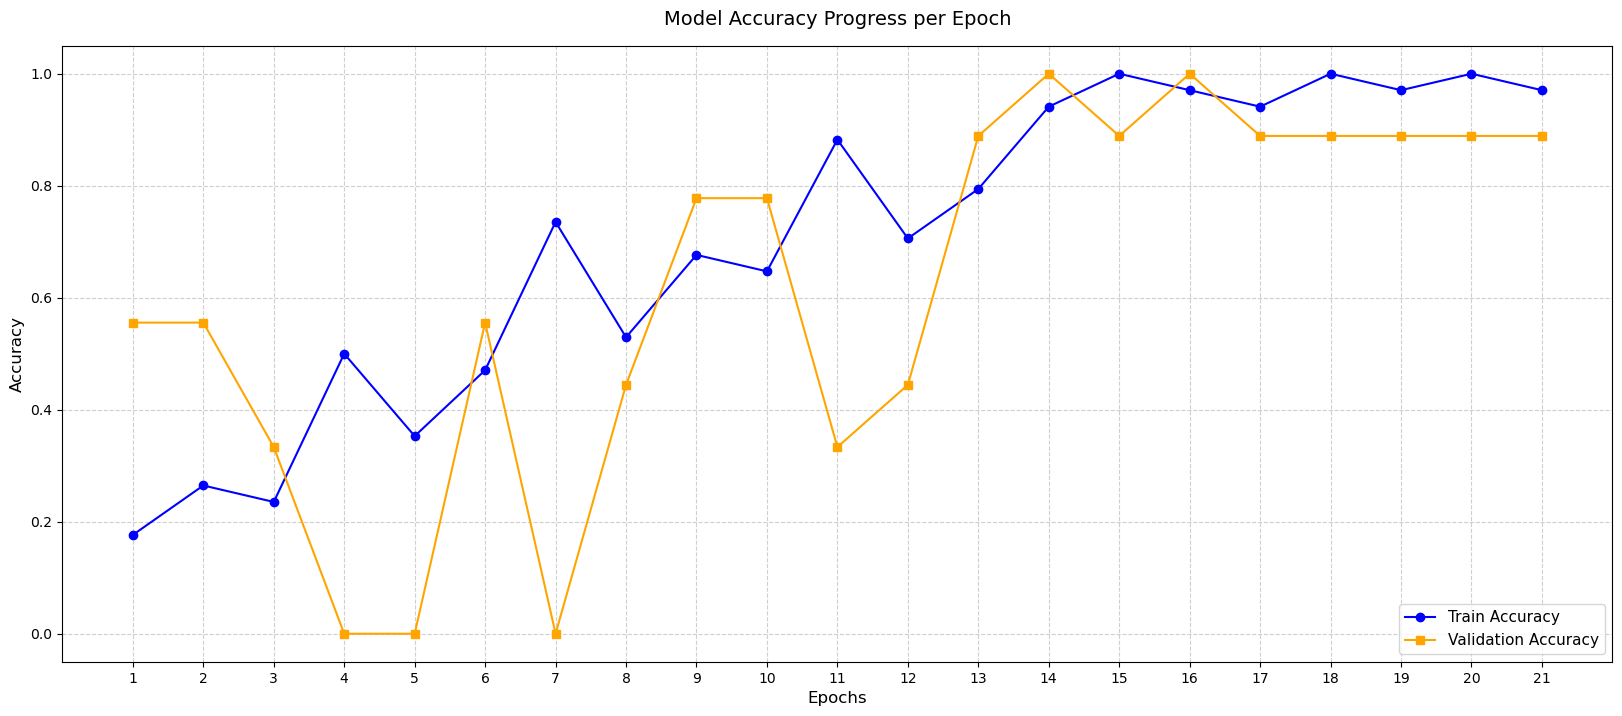

In [28]:
import matplotlib.pyplot as plt

# 1. history 객체에서 에포크별 train, valid 정확도 리스트 추출
train_acc_list = history.history['accuracy']
valid_acc_list = history.history['val_accuracy']

# 2. 에포크 수를 기준으로 x축 설정 (1부터 시작)
epochs_range = range(1, len(train_acc_list) + 1)

# 3. 그래프 그리기
plt.figure(figsize=(20, 8)) # 그래프 크기 설정
plt.plot(epochs_range, train_acc_list, label='Train Accuracy', marker='o', color='blue')
plt.plot(epochs_range, valid_acc_list, label='Validation Accuracy', marker='s', color='orange')

# 4. 그래프 꾸미기 (제목, 축 레이블, 범례 등)
plt.title('Model Accuracy Progress per Epoch', fontsize=14, pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(epochs_range) # x축 눈금을 에포크 정수로 고정
plt.grid(True, linestyle='--', alpha=0.6) # 배경 격자 추가
plt.legend(loc='lower right', fontsize=11) # 범례 위치 설정

# 5. 화면에 그래프 출력
plt.show()

> 그래프 해석  
1. 수치적 민감성 : 학습에 사용되는 데이터 수가 매우 적기 때문에 한 번의 오답으로도 정확도가 크게 흔들릴 수 있다  
ex.) 검증 데이터가 20개라면 1개만 틀려도 정확도가 5% 씩 흔들린다.  
2. '손실'과 '정확도'의 계산 방식 차이 : 손실값에 대한 그래프가 보다 안정적인 이유는 손실(loss)값 계산이 연속적이기 때문. 반면, 정확도를 측정할 때 Sigmoid 함수를 사용했기 때문에 이미지 판별 중 해당 이미지의 정답 확률이 0.5 미만 이면 모두 틀린(0)판정 처리되기 때문에 결론적으로 그래프가 크게 요동치는 것 처럼 보인다.  
3. DropOut 효과 : 위에 손실 그래프 처럼 DropOut 때문에 50%의 뉴런 만으로 정답판별 과정에서 '우연'에 의해 정답을 맞출 가능성이 충분히 있기 때문에 그래프가 크게 요동치는 것 처럼 보일 수 있다.

> 결론 : Loss 그래프를 참조했을 때, 실제 모델은 안정적으로 학습이 이루어졌다. 딥 러닝 모델이 안정적으로 학습했는지 판단하는 최우선 기준은 항상 'Loss 그래프' 인 것을 잊지말것 !